# Initialisation

In [3]:
%matplotlib inline
import numpy as np
from numpy import ma
from tabulate import tabulate

import yaml
import re
import pandas as pd
import glob
import subprocess
import tarfile

import datetime
import glob, os
from pathlib import Path
# get the current date and time
now = datetime.datetime.now()

from os.path import expanduser
import sys
import shutil, fnmatch
from linecache import getline
from pylab import *
from tqdm import tqdm

# matplotlib
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
from matplotlib import colors
from matplotlib.animation import FuncAnimation

# scipy
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import griddata

# spatial data
from osgeo import gdal
import shapely

############
# clawpack #
############
home        = expanduser("~")   # home directory
file_format = 'binary'          # format for files fortq*
# clawpack
from clawpack.geoclaw import topotools as topo
from clawpack.visclaw import colormaps, frametools, geoplot, gridtools

from clawpack.visclaw import animation_tools
from clawpack.visclaw.plottools import pcolorcells
from clawpack.geoclaw import dtopotools, topotools, marching_front
from clawpack.geoclaw import util
from clawpack.pyclaw.solution import Solution
from clawpack.pyclaw import solution as solution
from clawpack.amrclaw import region_tools
from clawpack.geoclaw import fgmax_tools, fgout_tools
from clawpack.visclaw import plottools, geoplot

# jupyter
from jupyprint import jupyprint  
from IPython.display import display, FileLink, FileLinks, HTML
from IPython.display import Image, Markdown, Math, Video
import webbrowser

# latex
plt.rcParams['text.usetex'] = True

# various packages
import warnings
warnings.filterwarnings("ignore")

# AVAC module
from module_avac import check_claw, check_version, install_avac, import_configuration_files
from module_avac import check_raster, reading_raster_file_features, reading_raster_file, import_initial_condition
from module_avac import flatten_dict
from module_avac import export_claw_initiation_file, export_claw_dem
from module_avac import make_output, export_raster, make_animation
from module_avac import fn_eta, fn_ground, fn_h, fn_u
from module_avac import reload_avac

def maketopo(theta_rad, xlower = -40,xupper = 100, yupper = 5, ylower = -5, cell_size = 1, type='plane', z_ref=0, θ2_deg=5, x_t = 100, K=0.1):
    """
    Output topography file for the entire domain.
    The topography is a plane inclined at theta (in deg, absolute value) with respect to the horizontal if type = 'plane'
    The topography is a curved surface given z = fnc_curve if type != 'plane'
    """
    theta_rad = np.abs(theta_rad)
    if theta_rad > 1: print(f"check slope angle θ = {theta_rad:.2f}>1")
    nxpoints = int((xupper-xlower)/cell_size)+1
    nypoints = int((yupper-ylower)/cell_size)+1

    outfile  = "plane.topotype3.asc"     

    if (xlower+(nxpoints-1)*cell_size != xupper): print("check cell size for the x-direction")
    if (ylower+(nypoints-1)*cell_size != yupper): print("check cell size for the y-direction")

    topography = topo.Topography()
    x = linspace(xlower,xupper,nxpoints)
    y = linspace(ylower,yupper,nypoints)
    X_fine_grid, Y_fine_grid = np.meshgrid(x,y)
    if type == 'curved':
        Z = fnc_curve(X_fine_grid, Y_fine_grid,  theta_rad, θ2_deg, z_ref, K, x_t )
        print("I created the curved surface.")
    else:
        Z = fnc_plane(X_fine_grid, Y_fine_grid, theta_rad,z_ref)
        print("I created the inclined plane surface.")
    topography.x = x
    topography.y = y
    topography.Z = Z
    topography.write(outfile, topo_type=3, Z_format="%22.15e")

def fnc_plane(x, y, θ_rad ,z_ref):
    """
    inclined plane 
    """
    θ_1   = -θ_rad
    z = z_ref+np.tan(θ_1 )*x
    return z

def fnc_curve(x, y, θ_1, θ_2, z_ref, K ,x_t):
    """
    inclined planes intersecting at x = x_t (K corner curvature)
    """
    θ_1   = -np.deg2rad(θ_1)
    θ_2   = -np.deg2rad(θ_2)

    z = z_ref+np.tan(θ_1 )*x+(1+np.tanh(K*(x-x_t)))/2*(np.tan(θ_2 )*x-np.tan(θ_1 )*x+(np.tan(θ_1 )-np.tan(θ_2 )) *x_t)
    return z

# Configuration

## Loading parameters

In [4]:
# Claw path and version
CLAW = check_claw()
Language = 'English'
claw_version = check_version(CLAW)
working_directory = os.getcwd() 
result_directory  = os.path.join(working_directory, '_output')
directory_cf      = working_directory
print('-- General information --')
print(f"* Clawpack version {claw_version[0]}.{claw_version[1]} installed")
if claw_version[0] != 5 and claw_version[1]<11: 
    print("Error! This script may not work. Consider upgrading...")
else:
    print("* Clawpack up to date.")
print('* Claw directory: ',CLAW)
print('* Working directory: ',working_directory)
print('* Configuration file directory: ',directory_cf)
print('* Clawpack output directory: ',result_directory )
print(f'* Language for plots: {Language}')
#install_avac(verbosity=True)

-- General information --
* Clawpack version 5.14 installed
* Clawpack up to date.
* Claw directory:  /home/ancey/clawpack/
* Working directory:  /home/ancey/rupture_barrage
* Configuration file directory:  /home/ancey/rupture_barrage
* Clawpack output directory:  /home/ancey/rupture_barrage/_output
* Language for plots: English


In [5]:


μ  = 0.1 #np.tan(7*np.pi/180)
ξ  = 0
θ  = np.deg2rad(2)
d0 = 1
is_initial_free_surface_horizontal = False # type of free surface at time t = 0
type_initial_surface = 'horizontal' if is_initial_free_surface_horizontal else 'parallel'
if θ == 0.: is_initial_free_surface_horizontal = True
xb = -d0/np.tan(θ) if θ>0 and is_initial_free_surface_horizontal else -20
print(f"Back of the reservoir xb = {xb:0.2f} m")
# List all .asc files in current directory
shape_files  = list(Path('.').glob('*.shp'))
raster_files = list(Path('.').glob('*.asc'))

print("* Raster files in current directory:")
for file in raster_files:
    print(file.name)
print()
print("* Shapefiles in current directory:")
for file in shape_files:
    print(file.name)

raster_files_names = [raster.name for raster in raster_files]
shape_files_names  = [shapef.name for shapef in shape_files]

release     = {'d0':float(d0),'free_surface':'parallel', 'theta':float(θ), 'xb': float(xb)} #  

rheology    = {'model':'Voellmy','rho':1000,'mu':float(μ),'n':0,'tau_c':0.,'p':1., 'gravity':9.81,'friction_forcing':False, 'Strickler':0}

topography  = {'dem':'plane.topotype3.asc','starting_areas':None,'type_dem':3, 'type_init':0}

computation = {'t_max':10,'nb_simul':10,'dry_limit':1e-6,'cfl_target':0.25,'cfl_max':0.5,\
               'refinement':1,'max_iter':100000, 
                'boundary_west':'wall','boundary_east':'extrap','boundary_south':'extrap','boundary_north':'extrap',\
                'output_directory':'_output','xlower':float(xb),'xupper':35,'ylower':-.5,'yupper':0.5,
                'dx':0.01,'dy':0.1,'limiter':'vanleer'}  # limiter : 'none', 'superbee','mc','vanleer', 'minmod'

output      = {'delta_t':1,'output_format':'binary32','verbosity':0}

animation   = {'n_out':100,'variable':'depth'}

date = {'date':now}

grid = {'xmin':int(1.1*xb),'xmax':35,'ymin':-0.5,'ymax':0.5,'dx':0.025,'dy':0.1}

Back of the reservoir xb = -20.00 m
* Raster files in current directory:

* Shapefiles in current directory:


In [6]:
parameters  = {'release':release,'rheology':rheology,'topography':topography, 
               'computation':computation,'output':output, 'animation':animation,'grid':grid,'date':date}


## Creating DEM

In [7]:

maketopo(float(θ),xlower=int(xb-10))
print(f"pente θ = {np.rad2deg(θ):0.2f}°")
parameters['topography']['dem'] = 'plane.topotype3.asc'

I created the inclined plane surface.
pente θ = 2.00°


## Loading DEM

In [8]:
if check_raster(parameters['topography']['dem']):
    print()
    print('Successful import.')
    xmin, xmax, ymin, ymax, nbx, nby, cell_size, dictionary_domain, _, _,_ = reading_raster_file_features(parameters['topography']['dem'])
else:
    print('Failed attempt to import the raster file')

Raster file: plane.topotype3.asc

File plane.topotype3.asc exists in the wording directory.

No problem detected in the raster file

Raster features
* The raster format is: claw.
* The grid type is: cell.

----------------------
Feature        Value
----------------------
xmin          -30.00
xmax          101.00
ymin           -5.00
ymax            6.00
nbx              131
nby               11
cell size       1.00

Successful import.


In [9]:
reload_avac()
from module_avac import reading_raster_file_features
xmin, xmax, ymin, ymax, nbx, nby, cell_size, dictionary_domain, _, _,_ = reading_raster_file_features(parameters['topography']['dem'])

Module reloaded successfully.


<Axes: >

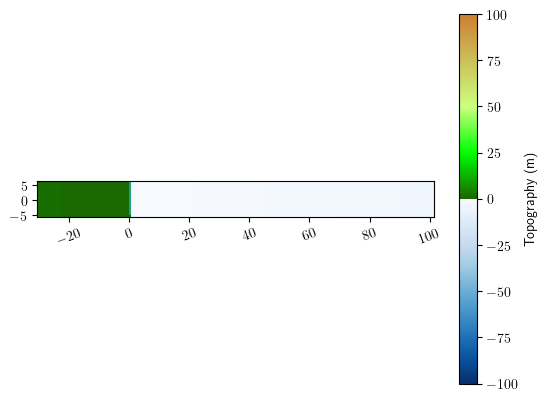

In [13]:
topo_file = reading_raster_file(parameters['topography']['dem'])
from math import ceil, floor
zmax = np.nanmax(topo_file.Z)
zmin = np.nanmin(topo_file.Z)
z_upper_bound = ceil(zmax / 100) * 100
z_lower_bound = floor(zmin / 100) * 100
topo_file.plot(limits=[z_lower_bound,z_upper_bound],contour_levels=[i for i in range(z_lower_bound,z_upper_bound,20)] ,long_lat=False)

# Running GeoClaw

In [14]:
configuration_dictionary = {
    'release':parameters['release'],
    'grid':parameters['grid'],
    'computation':parameters['computation'], 
    'rheology': parameters['rheology'], 
    'output': parameters['output'], 
    'dem_extent': dictionary_domain,
    'animation': parameters['animation'],
    'file_names':parameters['topography']}
flat_configuration = flatten_dict(configuration_dictionary)
print("Configuration file:")
for key, value in flat_configuration.items():
    var_name = key.replace('.', '_')
    globals()[var_name] = value
    print(f"* {var_name} = {value}")
file_name = 'geoclaw_configuration.yaml'
with open(file_name, 'w') as file:
    yaml.dump(configuration_dictionary, file)

print(f"Data has been written to {file_name}.")

Configuration file:
* release_d0 = 1.0
* release_free_surface = parallel
* release_theta = 0.03490658503988659
* release_xb = -20.0
* grid_xmin = -22
* grid_xmax = 35
* grid_ymin = -0.5
* grid_ymax = 0.5
* grid_dx = 0.025
* grid_dy = 0.1
* computation_t_max = 10
* computation_nb_simul = 10
* computation_dry_limit = 1e-06
* computation_cfl_target = 0.25
* computation_cfl_max = 0.5
* computation_refinement = 1
* computation_max_iter = 100000
* computation_boundary_west = wall
* computation_boundary_east = extrap
* computation_boundary_south = extrap
* computation_boundary_north = extrap
* computation_output_directory = _output
* computation_xlower = -20.0
* computation_xupper = 35
* computation_ylower = -0.5
* computation_yupper = 0.5
* computation_dx = 0.01
* computation_dy = 0.1
* computation_limiter = vanleer
* rheology_model = Voellmy
* rheology_rho = 1000
* rheology_mu = 0.1
* rheology_n = 0
* rheology_tau_c = 0.0
* rheology_p = 1.0
* rheology_gravity = 9.81
* rheology_friction_forc

In [54]:
make_output(parameters,verbosity=False)

I will make an AVAC computation.
Times: from t = 0 to t = 10 s with a time step dt = 1.0 s.


Makefile:81: avertissement : surchargement de la recette pour la cible « all »
/home/ancey/clawpack//clawutil/src/Makefile.common:327: avertissement : ancienne recette ignorée pour la cible « all »


rm -f xgeoclaw                    b4step2.f90.html module_rheology.f90.html qinit.f90.html setprob.f90.html src2.f90.html  make_fgout_animation.py.html maketopo.py.html module_avac_old.py.html module_avac.py.html module_solution.py.html setplot.py.html setrun.py.html adjoint.data.html amr.data.html claw.data.html dtopo.data.html fgmax.data.html fgmax_grids.data.html fgout_grids.data.html fixed_grids.data.html flagregions.data.html friction.data.html gauges.data.html geoclaw.data.html multilayer.data.html qinit.data.html refinement.data.html regions.data.html setprob.data.html surge.data.html topo.data.html   Makefile.html
rm -f .data .output .plots .htmls 
Computation is successful.


# Solutions

## Loading the solution (fgmax) and defining the color maps

In [15]:
outdir = '_output'
t_files = glob.glob(outdir + '/fort.t0*')
times = []
for f in t_files:
    lines = open(f,'r').readlines()
    for line in lines:
        if 'time' in line: 
            t = float(line.split()[0])
    times.append(t)
times.sort()
print('Output times found: ',times)


Output times found:  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


In [16]:
# Read fgmax data:
fgno = 1 # grid number 1
fg = fgmax_tools.FGmaxGrid()
fg.read_fgmax_grids_data(fgno)
fg.read_output(outdir=outdir)

Reading input for fgno=1, point_style = 2 
Reading _output/fgmax0001.txt ...


In [17]:
# Fields to be computed
velocity = ma.masked_where(fg.h<0.001, fg.s )
depth    = ma.masked_where(fg.h<0.001, fg.h )
ρ        = rheology['rho']
pressure = 0.5*ρ*velocity**2/1e3
pressure.fill_value = -9999
depth.fill_value = -9999
velocity.fill_value = -9999

In [18]:
ϵ = 1e-6 # minimum value
#depth
bounds_depth = np.array([ϵ,0.05,0.1,0.2,0.4,0.6,0.8,1])*release['d0']
cmap_depth   = colors.ListedColormap([[.9,.9,1],[.6,.6,1],\
                 [.3,.3,1],[0,0,1], [1,.8,.8],\
                 [1,.6,.6], [1,0,0]])

# pressure (kPa)
bounds_pressure = np.array([ϵ,0.05,0.1,0.2,.4,0.6,0.8,1])*2*release['d0']*rheology['gravity']*rheology['rho']/1000
cmap_pressure   = colors.ListedColormap([[.9,.9,1],[.6,.6,1],\
                 [.3,.3,1],[0,0,1], [1,.8,.8],\
                 [1,.6,.6], [1,0,0]])

# velocity norm
bounds_speed = np.array([ϵ,0.05,0.1,0.2,.4,0.6,0.8,1])*np.sqrt(2*release['d0']*rheology['gravity'])
cmap_speed   = colors.ListedColormap([[.9,.9,1],[.6,.6,1],\
                 [.3,.3,1],[0,0,1], [1,.8,.8],\
                 [1,.6,.6], [1,0,0]])

# Set color for value exceeding top of range to purple if needed:
cmap_speed.set_over(color=[1,0,1])
cmap_depth.set_over(color=[1,0,1])
cmap_pressure.set_over(color=[1,0,1])

# Set color for land points with too low values to light green if needed:
cmap_speed.set_under(color=[.7,1,.7])
cmap_depth.set_under(color=[.7,1,.7])
cmap_pressure.set_under(color=[.7,1,.7])

# Normalization
norm_speed = colors.BoundaryNorm(bounds_speed, cmap_speed.N)
norm_depth = colors.BoundaryNorm(bounds_depth, cmap_depth.N)
norm_pressure = colors.BoundaryNorm(bounds_pressure, cmap_pressure.N)

## Plot on contours

Origin point: (xmin = -30.00, ymin = -5.00) 


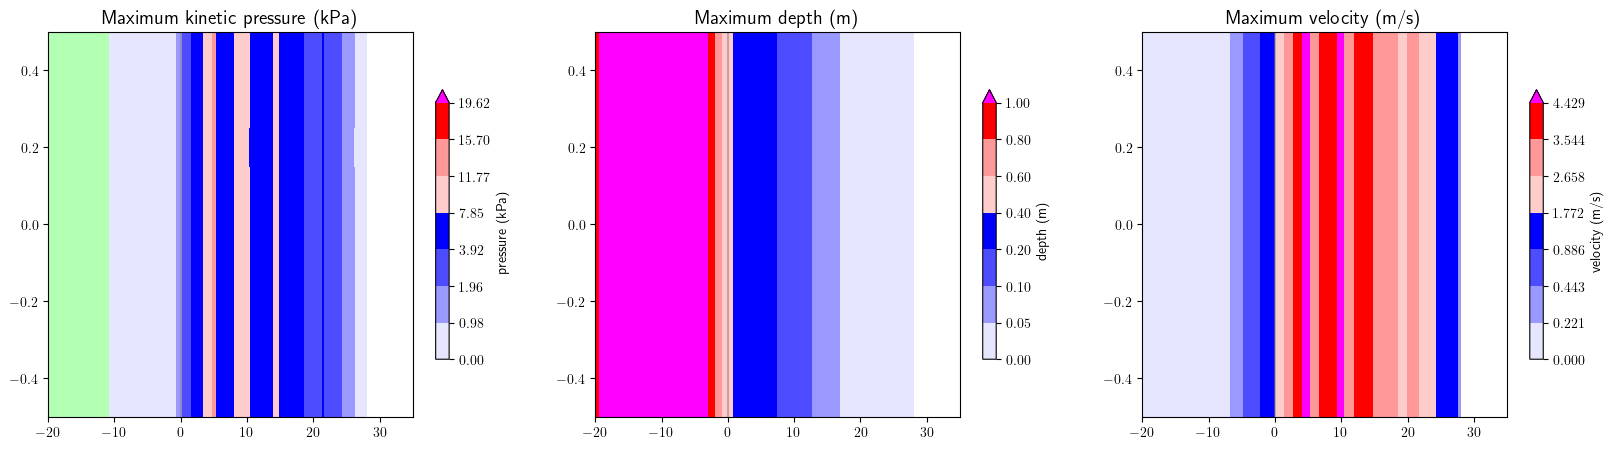

In [19]:
# Plot with contour lines
fig, ((ax1, ax2,ax3)) = plt.subplots(1,3)
fig.set_figheight(5)
fig.set_figwidth(20)
# Set aspect ratio for EACH subplot individually
# ax1.set_aspect('equal')
# ax2.set_aspect('equal')
# ax3.set_aspect('equal')
ax1.set_ylim([computation['ylower'],computation['yupper']])
ax2.set_ylim([computation['ylower'],computation['yupper']])
ax3.set_ylim([computation['ylower'],computation['yupper']])
ax1.set_xlim([computation['xlower'],computation['xupper']])
ax2.set_xlim([computation['xlower'],computation['xupper']])
ax3.set_xlim([computation['xlower'],computation['xupper']])

#plt.gca().set_aspect(1)
ax1.contour(fg.X, fg.Y, ma.masked_where(fg.B<z_lower_bound, fg.B), \
            levels=range(z_lower_bound,z_upper_bound,10), colors='grey',alpha=0.5,linewidth=.1) 
pc1 = pcolorcells(fg.X, fg.Y, pressure, cmap=cmap_pressure, norm=norm_pressure,ax=ax1)


ax2.contour(fg.X, fg.Y, ma.masked_where(fg.B<z_lower_bound, fg.B), \
            levels=range(z_lower_bound,z_upper_bound,10), colors='grey',alpha=0.5)
pc2 = pcolorcells(fg.X, fg.Y, depth, cmap=cmap_depth, norm=norm_depth,ax=ax2)


ax3.contour(fg.X, fg.Y, ma.masked_where(fg.B<z_lower_bound, fg.B), \
            levels=range(z_lower_bound,z_upper_bound,10), colors='grey',alpha=0.5)
pc3 = pcolorcells(fg.X, fg.Y, velocity, cmap=cmap_speed, norm=norm_speed,ax=ax3)


if Language == 'French':
    ax1.set_title('Pression cinétique maximale (kPa)', fontsize=14, color='black')
    ax2.set_title("Hauteur maximale d'écoulement (m)", fontsize=14, color='black')
    ax3.set_title('Vitesse maximale (m/s)', fontsize=14, color='black')
    cb1 = plt.colorbar(pc1, extend='max', shrink=0.7,label='pression (kPa)')
    cb2 = plt.colorbar(pc2, extend='max', shrink=0.7,label='hauteur (m)')
    cb3 = plt.colorbar(pc3, extend='max', shrink=0.7,label='vitesse (m/s)')
else:
    ax1.set_title('Maximum kinetic pressure (kPa)', fontsize=14, color='black')
    ax2.set_title('Maximum depth (m)', fontsize=14, color='black')
    ax3.set_title('Maximum velocity (m/s)', fontsize=14, color='black')
    cb1 = plt.colorbar(pc1, extend='max', shrink=0.7,label='pressure (kPa)')
    cb2 = plt.colorbar(pc2, extend='max', shrink=0.7,label='depth (m)')
    cb3 = plt.colorbar(pc3, extend='max', shrink=0.7,label='velocity (m/s)')


print(f"Origin point: (xmin = {xmin:0.2f}, ymin = {ymin:0.2f}) ")

In [20]:
fig.savefig('result_max_over_contours.png',dpi=300,bbox_inches='tight')

## Runout

In [21]:
threshold_h = computation['dry_limit']
x_runout = np.max(fg.X[fg.h>threshold_h]) 

display(Markdown(f"Runout position (point of furthest reach): $x = {x_runout:.2f}$ m."))


Runout position (point of furthest reach): $x = 28.40$ m.

## Cross-section of maximum depth

Origin point: (xmin = -30.00, ymin = -5.00) 


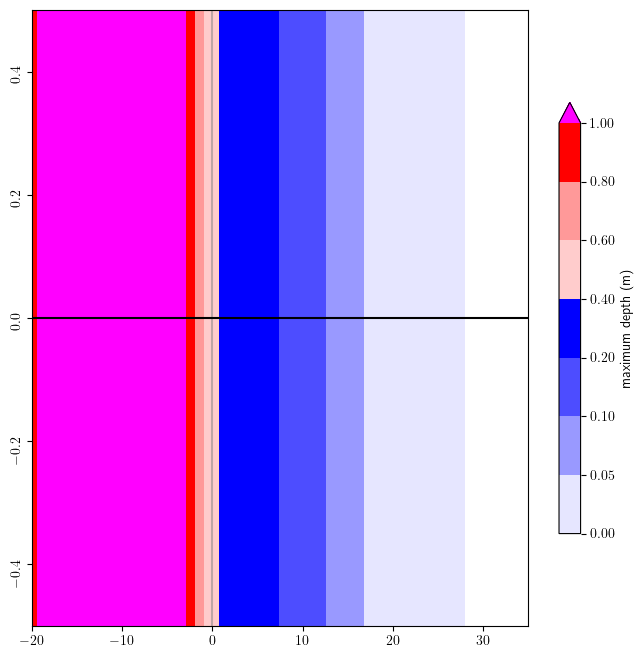

In [22]:
# cross-section
x_ref = 0
y_ref = 0


x_0, x_1 = x_ref + computation['xlower'], x_ref + computation['xupper']
y_0, y_1 = y_ref + 0, y_ref + 0

fig  = plt.figure(figsize=(8,8))
axes = plt.subplot(1, 1, 1)
axes.set_ylim([computation['ylower'],computation['yupper']])
axes.set_xlim([computation['xlower'],computation['xupper']])

axes.contour(fg.X, fg.Y, ma.masked_where(fg.B<z_lower_bound, fg.B), \
            levels=range(z_lower_bound,z_upper_bound,10), colors='grey',alpha=0.5)
pc = pcolorcells(fg.X, fg.Y, depth, cmap=cmap_depth, norm=norm_depth, ax=axes)
cb = plt.colorbar(pc, extend='max', shrink=0.7)
axes.plot([x_0,x_1],[y_0,y_1],color='black')
if Language == 'French':
    cb.set_label('hauteur maximale (m)')
else:
    cb.set_label('maximum depth (m)')

 

#gca().set_aspect(1)
ticklabel_format(useOffset=False)
yticks(rotation=90)

print(f"Origin point: (xmin = {xmin:0.2f}, ymin = {ymin:0.2f}) ")

Cross-Section from (-20, 0) to (35, 0)


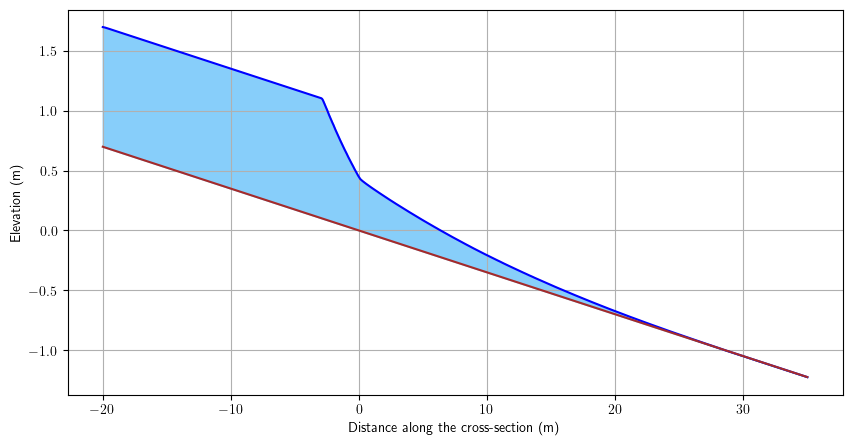

In [23]:
# plotting the deposit cross-section

dem1 = fg.B.T
dem2 = fg.h.T



x_coords = fg.X[:, 0]  # First column
y_coords = fg.Y[0, :]  # First row

# Replace masked values with NaN for interpolation
dem1_filled = dem1.filled(np.nan)
dem2_filled = dem2.filled(np.nan)

# Create the interpolator
interpolator = RegularGridInterpolator(
    (y_coords, x_coords),  # Grid coordinates (note: y comes first!)
    dem1_filled,           # DEM data (with NaN for masked values)
    method='linear',       # Interpolation method ('linear', 'nearest', etc.)
    bounds_error=False,    # Allow extrapolation (return NaN outside the grid)
    fill_value=np.nan      # Fill value for points outside the grid
)

# Create the interpolator fro depth
interpolator_h = RegularGridInterpolator(
    (y_coords, x_coords),    # Grid coordinates (note: y comes first!)
    dem1_filled+dem2_filled, # DEM data (with NaN for masked values)
    method='linear',         # Interpolation method ('linear', 'nearest', etc.)
    bounds_error=False,      # Allow extrapolation (return NaN outside the grid)
    fill_value=np.nan        # Fill value for points outside the grid
)

# Create a line between (x0, y0) and (x1, y1)
num_points = 1000  # Number of points along the cross-section
x_line = np.linspace(x_0, x_1, num_points)
y_line = np.linspace(y_0, y_1, num_points)

# Interpolate the DEM values along the line
points = np.column_stack((y_line, x_line))  # Note: y comes first!
cross_section = interpolator(points)
depth_section = interpolator_h(points)
 

# Calculate the distance along the profile
distance = x_line #np.sqrt((x_line - x_0)**2 + (y_line - y_0)**2)

# Plot the cross-section
plt.figure(figsize=(10, 5))
plt.fill_between(distance, depth_section, cross_section, color='lightskyblue')
plt.plot(distance, depth_section, label="Cross-Section",color='blue')
plt.grid(True)
plt.plot(distance, cross_section, label="Cross-Section",color='brown')

if Language == 'French':
    plt.xlabel("Distance depuis le point origine (m)")
    plt.ylabel("Altitude (m)")
else:
    plt.xlabel("Distance along the cross-section (m)")
    plt.ylabel("Elevation (m)")


print(f"Cross-Section from ({x_0:0.0f}, {y_0:0.0f}) to ({x_1:0.0f}, {y_1:0.0f})")

#plt.legend()
plt.show()

# Export to Qgis

In [24]:
# Exporting the rasters for Qgis
export_raster('depth_max.asc',depth.filled(),xmin,ymin,parameters['computation']['dx'],ndata=-9999)
export_raster('pressure_max.asc',pressure.filled(),xmin,ymin,parameters['computation']['dx'],ndata=-9999)
export_raster('velocity_max.asc',velocity.filled(),xmin,ymin,parameters['computation']['dx'],ndata=-9999)

# Make animation

In [25]:
make_animation(parameters,verbosity=False)
url_animation = working_directory + '/AVAC_animation_for_'+parameters['animation']['variable']+'.html'
path_animation = working_directory + '/AVAC_animation_for_'+parameters['animation']['variable']+'.mp4'

I will make an animation for the depth variable.
Times: from t = 0 to t = 10 s with a time step dt = 0.1 s.
Creation of the mp4 file: AVAC_animation_for_depth.mp4 in the working directory.
Creation of the html file: AVAC_animation_for_depth.html in the working directory.


In [26]:
# display in your brower

print('\n Link to animation file: ', url_animation)
#webbrowser.open(url_animation)


 Link to animation file:  /home/ancey/rupture_barrage/AVAC_animation_for_depth.html


In [27]:
# display in the jupyter notebook
Video(path_animation, width=800, height=800)

# Plotting the solution (final solution or at a given time) from fgout

## Importing the data

In [28]:

fgno          = 1
outdir        = parameters['computation']['output_directory']
output_format = parameters['output']['output_format']
fgout_grid    = fgout_tools.FGoutGrid(fgno, outdir,output_format)
fgout_grid.read_fgout_grids_data() # required as of v5.11.0

fgframe = parameters['animation']['n_out']  # last time
fgout = fgout_grid.read_frame(fgframe)

Reading fgout grid info from 
    _output/fgout_grids.data
Reading input for fgno=1, point_style = 2 
Found fgout grid q_out_vars =  [1, 2, 3, 4]
Using this mapping to fgout variable names: 
      qmap =  {'h': 1, 'hu': 2, 'hv': 3, 'eta': 4, 'B': 5}
    Reading  Frame 100 at t = 10  from outdir = /home/ancey/rupture_barrage/_output


## Mapping the depth

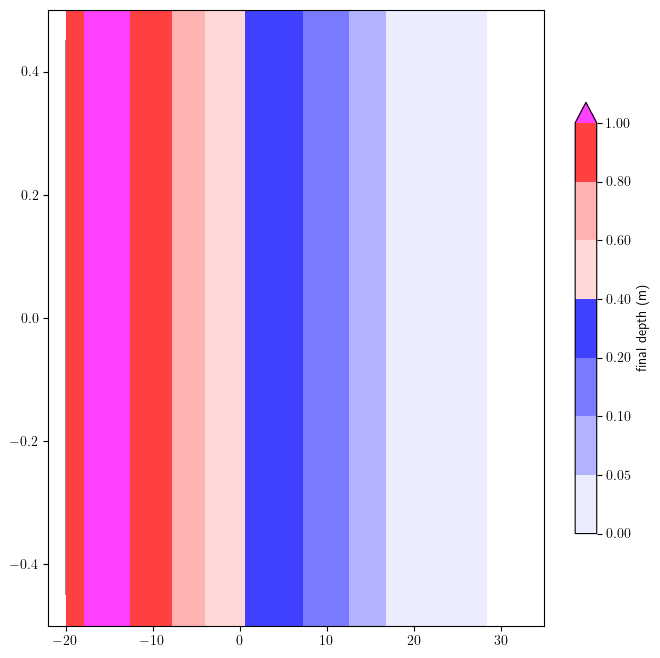

In [29]:
#  DEM  
bottom = fgout.B
depth  = ma.masked_where(fgout.h == 0, fgout.h)

# Mask NaN values
masked_dem = np.ma.masked_invalid(bottom)

# Compute gradients in the x and y directions, ignoring NaN values
gradient_x, gradient_y = np.gradient(bottom, cell_size)

# Define the light source direction (azimuth and altitude)
azimuth = 315   # Angle of the light source (in degrees, 0 = North, 90 = East, etc.)
altitude = 45   # Angle of the light source above the horizon (in degrees)

# Convert azimuth and altitude to radians
azimuth_rad = np.radians(azimuth)
altitude_rad = np.radians(altitude)

# Compute the illumination (hillshade)
illumination = (np.cos(altitude_rad) * np.cos(gradient_x) * np.sin(azimuth_rad) +
                np.cos(altitude_rad) * np.sin(gradient_y) * np.cos(azimuth_rad) +
                np.sin(altitude_rad) * np.cos(gradient_x) * np.cos(gradient_y))

# Normalize the illumination to the range [0, 1]
illumination = (illumination - illumination.min()) / (illumination.max() - illumination.min())

opacity = 0.75
fig  = plt.figure(figsize=(8,8))
axes = plt.subplot(1, 1, 1)
gca().set_aspect(1)
axes.imshow(illumination.T, cmap='gray', origin='lower', extent=[fgout.X.min(), fgout.X.max(), fgout.Y.min(), fgout.Y.max()],aspect='auto')
pc1 = pcolorcells(fgout.X, fgout.Y, depth, cmap=cmap_depth, norm=norm_depth,ax=axes,alpha=opacity)
cb1 = plt.colorbar(pc1, extend='max', shrink=0.7)


if Language == 'French':
    cb1.set_label('hauteur finale (m)')
else:
    cb1.set_label('final depth (m)')


Origin point: (xmin = -30.00, ymin = -5.00) 


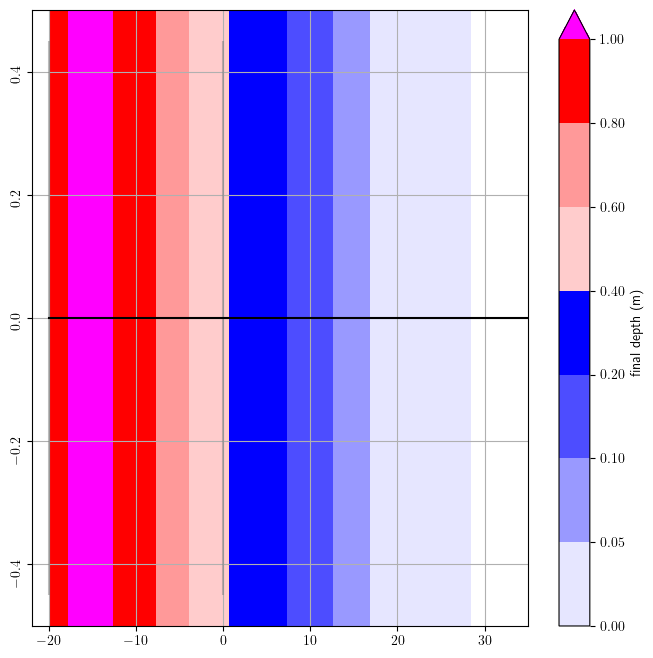

In [30]:
# cross-section
x_ref = 0
y_ref = 0

x_0, x_1 = x_ref + computation['xlower'], x_ref + computation['xupper']
y_0, y_1 = y_ref + 0, y_ref + 0

fig  = plt.figure(figsize=(8,8))
axes = plt.subplot(1, 1, 1)
axes.contour(fgout.X, fgout.Y, ma.masked_where(fgout.B<z_lower_bound, fgout.B), \
            levels=range(z_lower_bound,z_upper_bound,10), colors='grey',alpha=0.5)
pc = pcolorcells(fgout.X, fgout.Y, depth, cmap=cmap_depth, norm=norm_depth, ax=axes)
cb = plt.colorbar(pc, extend='max', shrink=1)
if Language == 'French':
    cb.set_label('hauteur finale (m)')
else:
    cb.set_label('final depth (m)')
# contour(fg.X, fg.Y, velocity, [0], colors='g')

#plt.gca().set_aspect(1)
axes.ticklabel_format(useOffset=False)
plt.yticks(rotation=90)
axes.plot([x_0,x_1],[y_0,y_1],color='black')
print(f"Origin point: (xmin = {xmin:0.2f}, ymin = {ymin:0.2f}) ")
axes.grid()

## Plotting the cross-section

Cross-Section from (-20, 0) to (35, 0)


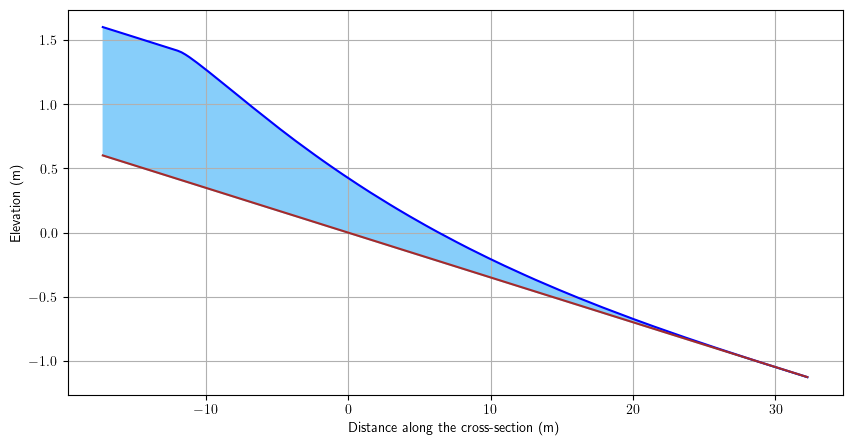

In [31]:
# plotting the deposit cross-section
dem1 = fgout.B.T
dem2 = fgout.h.T

# Create a grid of (x, y) coordinates for the DEM
x_coords = fgout.X[:,0] # First column
y_coords = fgout.Y[0,:] # First row
#xx, yy   = np.meshgrid(x_coords, y_coords)

# Replace masked values with NaN for interpolation
dem1_filled = dem1 
dem2_filled = dem2 

# Create the interpolator
interpolator = RegularGridInterpolator(
    (y_coords, x_coords),   # Grid coordinates 
    dem1_filled,            # DEM data with NaN for masked values
    method       = 'linear',        # Interpolation method. Select: 'linear', 'nearest', see doc
    bounds_error = False,     # Allow extrapolation (return NaN outside the grid)
    fill_value   = np.nan       # Fill value = nan for points outside the grid
)

# Create the interpolator
interpolator_h = RegularGridInterpolator(
    (y_coords, x_coords),    
    dem1_filled+dem2_filled, 
    method        = 'linear',      
    bounds_error  = False,     
    fill_value    = np.nan        
)

# Profile between (x0, y0) and (x1, y1)
num_points = 200  # Number of points along the cross-section
x_line = np.linspace(computation['xlower'], computation['xupper'], num_points)
y_line = np.linspace(computation['ylower'], computation['yupper'], num_points)

# Interpolate the DEM values along the line
points = np.column_stack((y_line, x_line))   
cross_section = interpolator(points)
depth_section = interpolator_h(points)
 

# Calculate the distance along the cross-section
distance = x_line #np.sqrt((x_line - x_0)**2 + (y_line - y_0)**2)

# Plot the cross-section
plt.figure(figsize=(10, 5))
plt.fill_between(distance, depth_section, cross_section, color='lightskyblue')
plt.plot(distance, depth_section, label="Cross-Section",color='blue')
plt.grid(True)
plt.plot(distance, cross_section, label="Cross-Section",color='brown')

if Language == 'French':
    plt.xlabel("Distance depuis le point origine (m)")
    plt.ylabel("Altitude (m)")
else:
    plt.xlabel("Distance along the cross-section (m)")
    plt.ylabel("Elevation (m)")

print(f"Cross-Section from ({x_0:0.0f}, {y_0:0.0f}) to ({x_1:0.0f}, {y_1:0.0f})")

#plt.legend()
plt.show()

### Variant

Cross-Section from (-20, 0) to (35, 0) at time 10.0 s


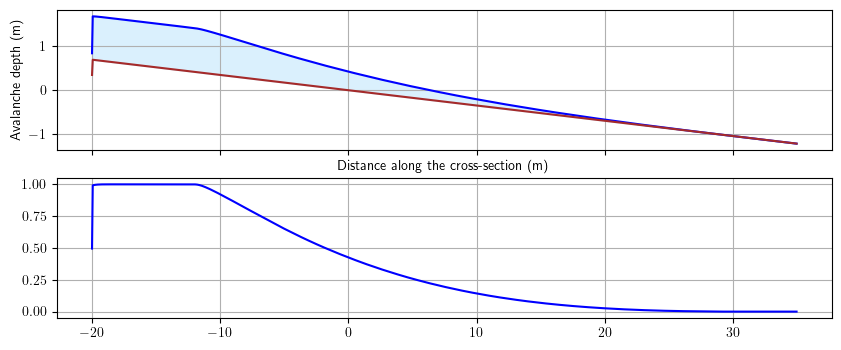

In [32]:
fgframe = parameters['computation']['t_max']
fgframe = parameters['animation']['n_out']
 # last time
fgout = fgout_grid.read_frame(fgframe)

# Load data and transpose
dem1 = fgout.B.T  # DEM
dem2 = fgout.h.T  # Depth

# Fill masked values if necessary
dem1_filled = np.ma.filled(dem1, np.nan) if np.ma.is_masked(dem1) else dem1
dem2_filled = np.ma.filled(dem2, np.nan) if np.ma.is_masked(dem2) else dem2

# Create coordinate grid
x_coords = fgout.X[:,0] # First column
y_coords = fgout.Y[0,:] # First row

# Interpolators
interpolator_dem = RegularGridInterpolator(
    (y_coords, x_coords), dem1_filled, method='linear', bounds_error=False, fill_value=np.nan
)
interpolator_depth = RegularGridInterpolator(
    (y_coords, x_coords), dem2_filled, method='linear', bounds_error=False, fill_value=np.nan
)
interpolator_free_surface = RegularGridInterpolator(
    (y_coords, x_coords), dem1_filled + dem2_filled, method='linear', bounds_error=False, fill_value=np.nan
)

# Define cross-section line
num_points = 1000
x_line = np.linspace(x_0, x_1, num_points)
y_line = np.linspace(y_0, y_1, num_points)
points = np.column_stack((y_line, x_line))

# Interpolate
dem_section           = interpolator_dem(points)
depth_section         = interpolator_depth(points)
free_surface_section  = interpolator_free_surface(points)

# Compute distance (handles non-straight lines if needed)
dx = np.diff(x_line)
dy = np.diff(y_line)
segment_lengths = np.sqrt(dx**2 + dy**2)
distance        = x_line #np.concatenate(([0], np.cumsum(segment_lengths)))

# Plotting
 
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 4))
 

ax1.plot(distance, free_surface_section, 'blue', label="Avalanche Surface")
ax1.fill_between(distance, dem_section, free_surface_section, color='lightskyblue', alpha=0.3 )
ax1.plot(distance, dem_section, 'brown', label="ground")
if Language == 'French':
    ax1.set_xlabel("Distance depuis le point origine (m)")
    ax1.set_ylabel("Altitude (m)")
else:
    ax1.set_xlabel("Distance along the cross-section (m)")
    ax1.set_ylabel("Elevation (m)")

print(f"Cross-Section from ({x_0:0.0f}, {y_0:0.0f}) to ({x_1:0.0f}, {y_1:0.0f}) at time {fgout.t} s")

#plt.legend()
ax1.grid()


# depth profile
ax2.plot(distance, depth_section, 'blue', label="Avalanche Surface")
ax2.grid()
if Language == 'French':
    ax1.set_xlabel("Distance depuis le point origine (m)")
    ax1.set_ylabel("Épaisseur de l'avalanche (m)")
else:
    ax1.set_xlabel("Distance along the cross-section (m)")
    ax1.set_ylabel("Avalanche depth (m)")

plt.show()

In [33]:
fgout = fgout_grid.read_frame(1)  # Frame numbers start at 1
h     = fgout.h.T
B     = fgout.B.T
η     = h + B

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("Distance along cross-section (m)")
ax.set_ylabel("Elevation (m)")
ax.grid()

# Create all artists
dem_line, = ax.plot(distance, dem_section, 'brown', label="Terrain")
ax.set_ylim([B.min(),η.max()*1.1])
free_line, = ax.plot([], [], 'b-', label="Avalanche Surface")
depth_fill = ax.fill_between([], [], color='lightskyblue', alpha=0.5)

# Get frame information
nb_frames = parameters['animation']['n_out'] # Total number of frames
frame_indices = range(nb_frames)  # Frame numbers (0 to nb_frames-1)

def init():
    """Initialize animation"""
    free_line.set_data([], [])
    depth_fill.set_verts([])
    return free_line, depth_fill

def update(frame_index):
    """Update frame for given frame index"""
    try:
        fgout = fgout_grid.read_frame(frame_index + 1)  # Frame numbers start at 1
        h     = fgout.h.T
        B     = fgout.B.T
        
        # Interpolate Avalanche surface (B + h)
        free_surface = RegularGridInterpolator(
            (y_coords, x_coords), B + h,
            method='linear', bounds_error=False
        )(np.column_stack((y_line, x_line)))
        
        # Create proper closed polygon vertices
        verts = np.vstack([
            np.column_stack((distance, free_surface)),  # Avalanche surface
            [(distance[-1], dem_section[-1])],          # Bottom right
            np.flipud(np.column_stack((distance, dem_section))),  # Terrain
            [(distance[0], free_surface[0])]           # Close polygon
        ])
        
        # Update artists
        free_line.set_data(distance, free_surface)
        depth_fill.set_verts([verts])
        
        ax.set_title(f"Time = {fgout.t:.2f} seconds (Frame {frame_index + 1}/{nb_frames})")
        #ax.relim()
        #ax.autoscale_view()
        
    except Exception as e:
        print(f"Error processing frame {frame_index + 1}: {str(e)}")
        return init()
    
    return free_line, depth_fill


# Create animation
ani = FuncAnimation(
    fig, update, frames=frame_indices,
    init_func=init, blit=True, interval=100
)

# Display with multiple fallback options
plt.close()


    Reading  Frame 1 at t = 0  from outdir = /home/ancey/rupture_barrage/_output


In [34]:
%%capture --no-display 
# uncomment if you want to see the messages and progression
HTML(ani.to_jshtml())

2026-02-13 18:05:16,288 INFO CLAW: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


### Animation avalanche (with no terrain)

In [35]:
fgout  = fgout_grid.read_frame(1)  # Frame numbers start at 1
h      = fgout.h.T
B      = fgout.B.T
η      = h + B
ground = np.zeros_like(distance)
# --- Setup figure ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("Distance along cross-section (m)")
ax.set_ylabel("Elevation (m)")
ax.grid()

# Create all artists
dem_line, = ax.plot(distance, ground, 'brown', label="Terrain")
ax.set_ylim([0,h.max()*1.1])
free_line, = ax.plot([], [], 'b-', label="Avalanche Surface")
depth_fill = ax.fill_between([], [], color='lightskyblue', alpha=0.5)

# Get frame information
nb_frames = parameters['animation']['n_out'] # Total number of frames
frame_indices = range(nb_frames)  # Frame numbers (0 to nb_frames-1)

def init():
    """Initialize animation"""
    free_line.set_data([], [])
    depth_fill.set_verts([])
    return free_line, depth_fill

def update(frame_index):
    """Update frame for given frame index"""
    try:
        fgout = fgout_grid.read_frame(frame_index + 1)  # Frame numbers start at 1
        h     = fgout.h.T
         
        
        # Interpolate Avalanche surface (B + h)
        free_surface = RegularGridInterpolator(
            (y_coords, x_coords),  h,
            method='linear', bounds_error=False
        )(np.column_stack((y_line, x_line)))
        
        # Create proper closed polygon vertices
        verts = np.vstack([
            np.column_stack((distance, free_surface)),  # Avalanche surface
            [(distance[-1], ground[-1])],              # Bottom right
            np.flipud(np.column_stack((distance, ground))),  # Terrain
            [(distance[0], free_surface[0])]           # Close polygon
        ])
        
        # Update artists
        free_line.set_data(distance, free_surface)
        depth_fill.set_verts([verts])
        
        ax.set_title(f"Time = {fgout.t:.2f} seconds (Frame {frame_index + 1}/{nb_frames})")
        #ax.relim()
        #ax.autoscale_view()
        
    except Exception as e:
        print(f"Error processing frame {frame_index + 1}: {str(e)}")
        return init()
    
    return free_line, depth_fill


# Create animation
ani = FuncAnimation(
    fig, update, frames=frame_indices,
    init_func=init, blit=True, interval=100
)

# Display with multiple fallback options
plt.close()


    Reading  Frame 1 at t = 0  from outdir = /home/ancey/rupture_barrage/_output


In [38]:
%%capture --no-display 
# uncomment if you want to see the messages and progression
HTML(ani.to_jshtml())

# Depth and velocity profiles at different times

    Reading  Frame 1 at t = 0  from outdir = /home/ancey/rupture_barrage/_output
    Reading  Frame 11 at t = 1.0101  from outdir = /home/ancey/rupture_barrage/_output


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:07<00:00,  7.31s/it]


    Reading  Frame 21 at t = 2.0202  from outdir = /home/ancey/rupture_barrage/_output


100%|██████████| 1/1 [00:07<00:00,  7.23s/it]


...

100%|██████████| 1/1 [00:06<00:00,  6.25s/it]


    Reading  Frame 81 at t = 8.08081  from outdir = /home/ancey/rupture_barrage/_output


100%|██████████| 1/1 [00:06<00:00,  6.02s/it]


    Reading  Frame 91 at t = 9.09091  from outdir = /home/ancey/rupture_barrage/_output


100%|██████████| 1/1 [00:06<00:00,  6.09s/it]


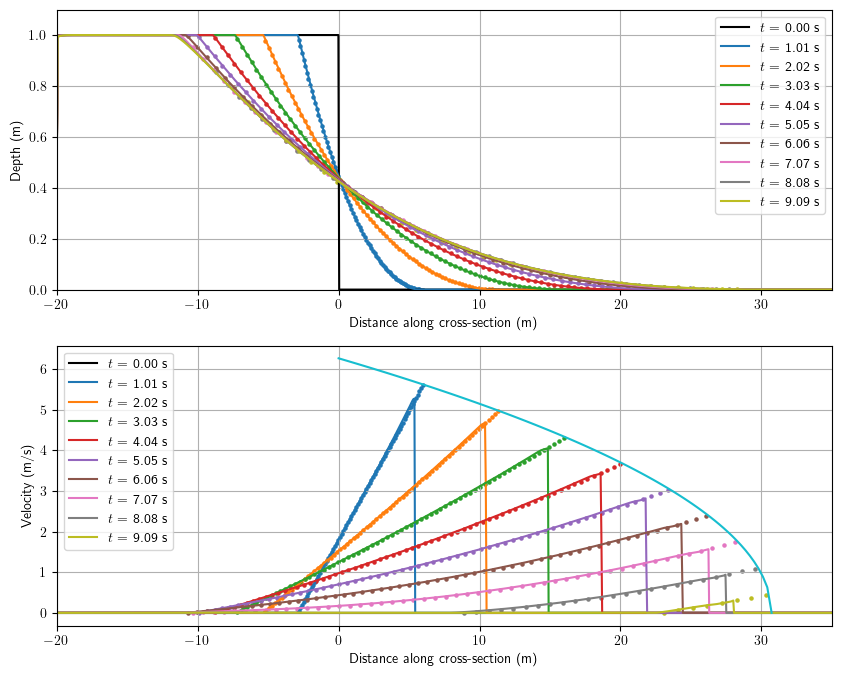

In [39]:
from module_solution import solution_h_u
#scales
μs   = rheology['mu']-np.tan(θ) 
gs   = rheology['gravity']*np.cos(θ)
K   = 1
h_0 = release['d0']
H0  = h_0
X0  = K/μs*h_0
U0  = np.sqrt(gs*H0*K)
T0  = np.sqrt(H0*K/gs)/μs

#print(f"T0 = {T0:0.2f} s")


# --- Setup of the figure ---
fig, ((ax, axu) ) = plt.subplots(2, 1)
fig.set_figheight(8)
fig.set_figwidth(10)
ax.set_xlabel("Distance along cross-section (m)")
ax.set_ylabel("Depth (m)")
ax.grid()
ax.set_xlim([-20,35])
ax.set_ylim([0,1.1])

axu.set_xlabel("Distance along cross-section (m)")
axu.set_ylabel("Velocity (m/s)")
axu.set_xlim([-20,35])
#ax.plot(distance, ground, 'brown', label="Terrain")

index_tps = [11,21,31,41,51,61,71,81,91] 

fgout = fgout_grid.read_frame(1) 
h     = fgout.h.T
u     = fgout.u.T
x_coords = fgout.X[:,0] # First column
y_coords = fgout.Y[0,:] # First row
num_points = 1000  # Number of points along the cross-section
x_line = np.linspace(computation['xlower'], computation['xupper'], num_points)
y_line = np.zeros_like(x_line)

free_surface = RegularGridInterpolator(
    (y_coords, x_coords),  h,
    method='linear', bounds_error=False
)(np.column_stack((y_line, x_line)))

# Interpolate Avalanche velocity in the x direction ( u)
streamwise_velocity = RegularGridInterpolator(
    (y_coords, x_coords),  u,
    method='linear', bounds_error=False
)(np.column_stack((y_line, x_line)))

ax.plot(x_line,free_surface,label = rf"$t$ = {fgout.t:.2f} s",color='black')
axu.plot(x_line,streamwise_velocity,label = rf"$t$ = {fgout.t:.2f} s",color='black')

effective_times = []
for t in index_tps:
    fgout = fgout_grid.read_frame(t)   
    h     = fgout.h.T
    u     = fgout.u.T
    effective_times.append(fgout.t)

    # Interpolate Avalanche surface ( h)
    free_surface = RegularGridInterpolator(
        (y_coords, x_coords),  h,
        method='linear', bounds_error=False
    )(np.column_stack((y_line, x_line)))

    # Interpolate Avalanche velocity in the x direction ( u)
    streamwise_velocity = RegularGridInterpolator(
        (y_coords, x_coords),  u,
        method='linear', bounds_error=False
    )(np.column_stack((y_line, x_line)))
    
    ax.plot(x_line,free_surface,label = rf"$t$ = {fgout.t:.2f} s")
    axu.plot(x_line,streamwise_velocity,label = rf"$t$ = {fgout.t:.2f} s")

    
    [solutions_xu,solutions_xh,solutions_u,solutions_h] = solution_h_u([fgout.t],T0)
    ax.scatter(solutions_xh[::5]*X0 ,solutions_h[::5]*H0, s = 5)
    axu.scatter(solutions_xu[::5]*X0 ,solutions_u[::5]*U0, s = 5)
        
ax.legend()

axu.legend()
axu.grid()
x_f = np.linspace(0,2,100)
axu.plot(x_f*X0,np.sqrt(4-2*x_f)*U0,label = r'$u_f = \sqrt{4-2x_f}$')
    

In [40]:
fig.savefig('depth-velocity-profiles8_theta.png',dpi=300,bbox_inches='tight')

# Plotting the last solution using fort.q* files

In [41]:

working_directory  = os.getcwd()
result_directory = os.path.join(working_directory, '_output')
sys.path.insert(0,working_directory)  

print('Directory that contains the data: \n  %s' % result_directory)
if not os.path.isdir(working_directory):
      print('*** Check output directory (I cannot find it)!')

fichiers = fnmatch.filter(os.listdir(result_directory), 'fort.q*' )
NbSim    = len(fichiers)
print(f"There are {NbSim} file fort.q*.")

Directory that contains the data: 
  /home/ancey/rupture_barrage/_output
There are 11 file fort.q*.


* xmin =  -20.00 m and xmax = 35.00 m; delta_x = 0.0 m.
* ymin =  -0.50 m and ymax = 0.50 m; delta_y = 0.1 m.
* There are 128 patches au temps t = 0.0 s.
* Initial time t = 0.0 s; final time t = 10.0 s; dt = 1.0 s.
* Number of simulations: 10.
Maximum initial depth 1.00 m.


Initial volume: 20   $\text{m}^3$ .

**** Digital elevation model (DEM) ****
* DEM lowest elevation: -3.5 m.  
* DEM highest elevation: 1.0 m.


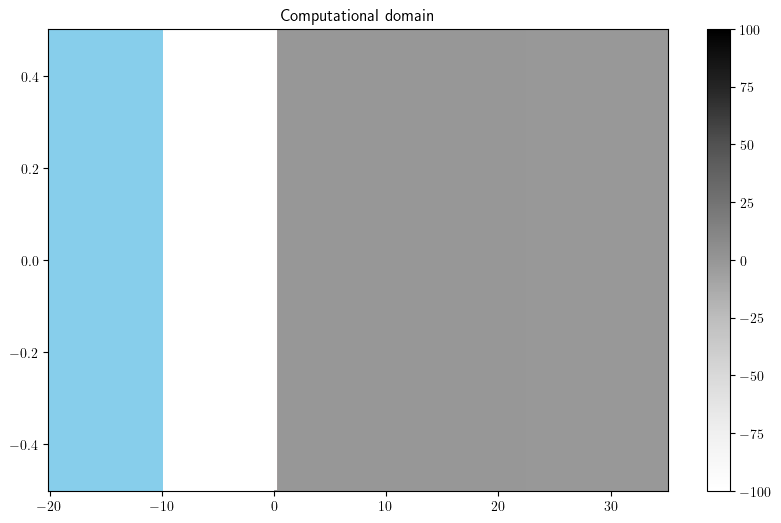

In [42]:
frame_0     = solution.Solution(0, path=result_directory, file_format=file_format)
frame_final = solution.Solution(NbSim-1, path=result_directory, file_format=file_format)

number_patches = len(frame_0.domain.patches)

t_0 = frame_0.t
t_f = frame_final.t
dt  = (t_f-t_0)/(NbSim-1)
xlower = []
xupper = []
ylower = []
yupper = []
for patch in frame_0.domain.patches:
      xlower.append(patch.grid.x.lower)
      xupper.append(patch.grid.x.upper)
      ylower.append(patch.grid.y.lower)
      yupper.append(patch.grid.y.upper)
xmin  = min(xlower)
xmax  = max(xupper)
ymin  = min(ylower)
ymax  = max(yupper)
delta = frame_0.patch.delta
print(f"* xmin =  {xmin:.2f} m and xmax = {xmax:.2f} m; delta_x = {delta[0]:.1f} m.")
print(f"* ymin =  {ymin:.2f} m and ymax = {ymax:.2f} m; delta_y = {delta[1]:.1f} m.")
print(f"* There are {number_patches} patches au temps t = {t_0} s.")
print(f"* Initial time t = {t_0} s; final time t = {t_f} s; dt = {dt} s.")
print(f"* Number of simulations: {NbSim-1}.")

# grid
nb_cells = 200
x = np.linspace(xmin,xmax,nb_cells)
y = np.linspace(ymin,ymax,nb_cells)
X_grid, Y_grid = np.meshgrid(x,y)
dx = (xmax-xmin)/nb_cells
dy = (ymax-ymin)/nb_cells

# interpolation of the solution 
sol_0     = gridtools.grid_output_2d(frame_0, fn_ground, X_grid, Y_grid, 
                                    levels='all',return_ma=True)
eta_0     = gridtools.grid_output_2d(frame_0, fn_eta, X_grid, Y_grid, 
                                      levels='all',return_ma=True)
depth_0 = gridtools.grid_output_2d(frame_0, fn_h, X_grid, Y_grid, 
                                      levels='all',return_ma=True)
eta_0.fill_value = np.NaN

volume_0 = int(depth_0.sum()*dx*dy)
print("Maximum initial depth {:.2f} m.".format(depth_0.max()))
jupyprint(f"Initial volume: {volume_0} "+"  $\\text{m}^3$ ." )

zmin = np.nanmin(topo_file.Z)
zmax = np.nanmax(topo_file.Z)
print("**** Digital elevation model (DEM) ****")
print(f"* DEM lowest elevation: {zmin:.1f} m.  ")
print(f"* DEM highest elevation: {zmax:.1f} m.")

figure(figsize=(10,6))
contour(X_grid, Y_grid, eta_0.filled(), colors='r',levels=[i for i in range(z_lower_bound,z_upper_bound,20)],color = 'orange',alpha=0.5,linewidth=0.1)
pcolormesh(X_grid, Y_grid, sol_0 ,cmap = 'Greys',norm=colors.Normalize(vmax=z_upper_bound,vmin=z_lower_bound) )
#clim(2000,3400)

threshold_h = computation['dry_limit']
eta_masque = ma.masked_where(depth_0 < threshold_h, eta_0)
#clim(-0.5,0.5)
colorbar()
pcolorcells(X_grid, Y_grid, eta_masque, cmap=colors.ListedColormap(['white', 'skyblue']) )
contour(X_grid, Y_grid, depth_0, colors='w')
#gca().set_aspect(1)


if Language == 'French':
    title('Domaine de calcul')
else:
    title('Computational domain')

In [43]:
# cross-section
x_ref = 0
y_ref = 0


x_0, x_1 = computation['xlower'],computation['xupper']
y_0, y_1 = y_ref + 0, y_ref + 0


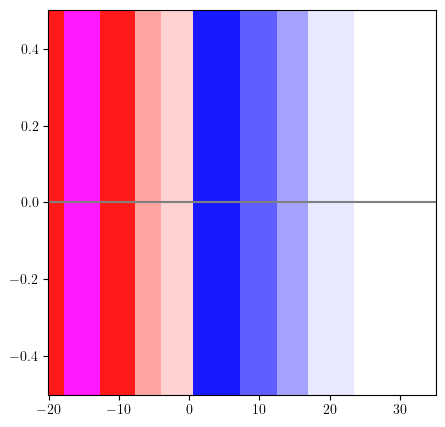

In [44]:
depth_f = gridtools.grid_output_2d(frame_final, fn_h, X_grid, Y_grid, 
                                    levels='all',return_ma=True) 
depth_f[depth_f<0.01] = np.nan
im_ratio = 1

fig, axs = plt.subplots(figsize=(5, 5))
#axs.pcolormesh(topo2.X,topo2.Y,topo2.Z,cmap='Greys',alpha=0.75)
#gca().set_aspect(im_ratio)

#axs.contour(X_grid,Y_grid,vague_masque[ii],colors='w')
pcolorcells(X_grid,Y_grid,depth_f, cmap=cmap_depth,norm = norm_depth,alpha=0.9 )
clim(0,10)
axs.plot([x_0,x_1],[y_0,y_1],color='gray')

In [45]:
# gfine grid
x = np.linspace(xmin,xmax,nbx)
y = np.linspace(ymin,ymax,nby)
X_grid, Y_grid = np.meshgrid(x,y)
dx = (xmax-xmin)/nb_cells
dy = (ymax-ymin)/nb_cells

# interpolation of the solution 
eta_f     = gridtools.grid_output_2d(frame_final, fn_eta, X_grid, Y_grid, 
                                      levels='all',return_ma=True)


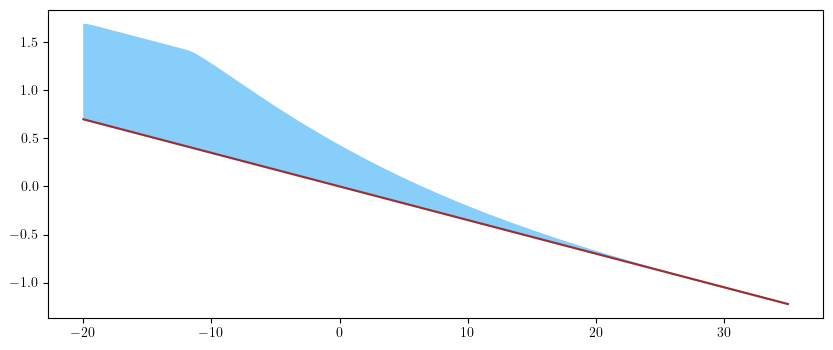

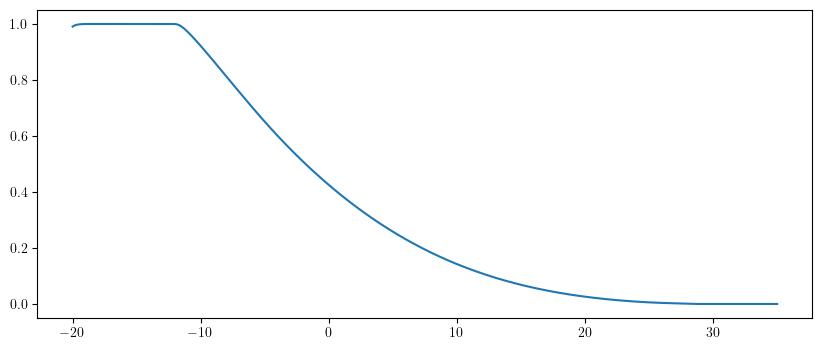

In [46]:


x_profile = np.linspace(x_0, x_1, 500)
y_profile = np.linspace(y_0, y_1, 500)
eta_out = gridtools.grid_output_2d(frame_final, fn_eta, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
sol_out = gridtools.grid_output_2d(frame_final, fn_ground, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
h_out   = gridtools.grid_output_2d(frame_final, fn_h, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
distance = x_profile #((x_profile-x_0*0)**2+(y_profile-y_0*0)**2)**0.5
 


figure(figsize=(10,4))
fill_between(distance, eta_out, sol_out, color='lightskyblue')
 
plot(distance, sol_out, color='brown')

figure(figsize=(10,4))
plot(distance, h_out )

In [47]:
#scales
μs   = rheology['mu']-np.tan(θ) 
gs   = rheology['gravity']*np.cos(θ)

# μs = μ
# gs = rheology['gravity']

K   = 1
h_0 = release['d0']
H0  = h_0
X0  = K/μs*h_0
U0  = np.sqrt(gs*H0*K)
T0  = np.sqrt(H0*K/gs)/μs
print(f"T0 = {T0:0.2f} s")

x_arrest = 2*X0
t_arrest = 2*T0
x_B      = -0.721577*X0
x_obs    = distance[h_out==1].max()


try:
    x_front  = distance[h_out < threshold_h].min()
    
except ValueError as e:
    print ('error type: ', type (e))
    x_front = distance.max()

T0 = 4.91 s


In [48]:
from jupyprint import jupyprint
print('***** Theory ******')
jupyprint(rf"$x_f =  {x_arrest:0.2f}$ m and $x_b= {x_B:0.2f}$ m")
jupyprint(rf"$t_f = $ {t_arrest:0.2f} s")
print('***** Measured ******')
jupyprint(f"observed $x_b = {x_obs:0.2f}$ m")
jupyprint(f"observed $x_f = {x_front:0.2f}$ m")

***** Theory ******


$x_f =  30.73$ m and $x_b= -11.09$ m

$t_f = $ 9.81 s

***** Measured ******


observed $x_b = -13.06$ m

observed $x_f = 28.50$ m

100%|██████████| 1/1 [00:06<00:00,  6.27s/it]


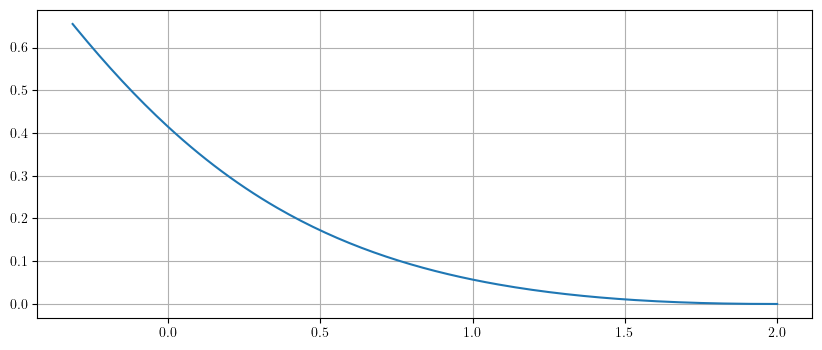

In [49]:

from module_solution import solution_h_u
[solutions_xu,solutions_xh,solutions_u,solutions_h] = solution_h_u([2*T0],T0)

fig = plt.figure(figsize=(10,4))
ax = plt.subplot(1, 1, 1)





ax.plot(solutions_xh ,solutions_h )
ax.grid()

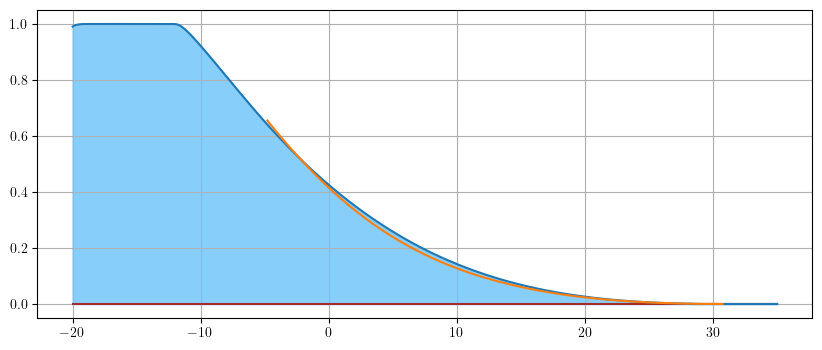

In [50]:
x_profile = np.linspace(x_0, x_1, 500)
y_profile = np.linspace(y_0, y_1, 500)
eta_out = gridtools.grid_output_2d(frame_final, fn_eta, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
# sol_out = gridtools.grid_output_2d(frame_final, fn_ground, x_profile, y_profile, 
#                                  levels='all',return_ma=True,method='linear')
h_out   = gridtools.grid_output_2d(frame_final, fn_h, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
distance = x_profile #((x_profile-x_0)**2+(y_profile-y_0)**2)**0.5
np.zeros_like(h_out)


fig = figure(figsize=(10,4))
ax = subplot(1,1,1)
ax.fill_between(distance, h_out, np.zeros_like(h_out), color='lightskyblue')
 
ax.plot(distance, np.zeros_like(h_out), color='brown')

ax.plot(distance, h_out )
ax.plot(solutions_xh*X0,solutions_h*H0)
ax.grid()

In [51]:
from module_avac import fn_eta, fn_ground, fn_h, fn_u, fn_hu

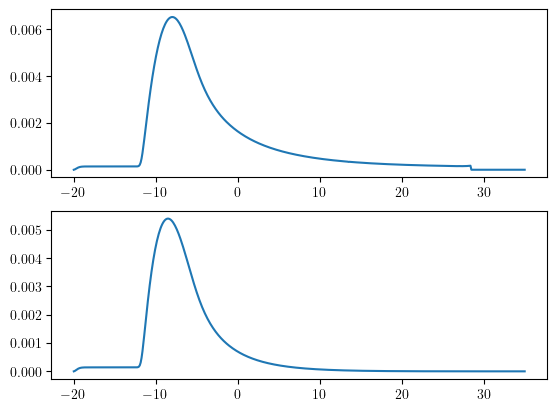

In [52]:
u_out   = gridtools.grid_output_2d(frame_final, fn_u, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
distance = x_profile #((x_profile-x_0)**2+(y_profile-y_0)**2)**0.5
hu_out   = gridtools.grid_output_2d(frame_final, fn_hu, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
 

 
fig, ((ax1, ax2) ) = plt.subplots(2,1)
 
#ax.plot(distance, sol_out, color='brown')

ax1.plot(distance,u_out)
ax2.plot(distance,hu_out)

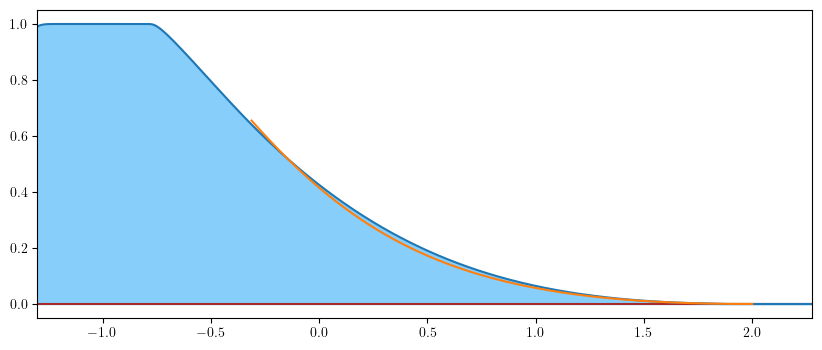

In [53]:
x_profile = np.linspace(x_0, x_1, 500)
y_profile = np.linspace(y_0, y_1, 500)
eta_out = gridtools.grid_output_2d(frame_final, fn_eta, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
# sol_out = gridtools.grid_output_2d(frame_final, fn_ground, x_profile, y_profile, 
#                                  levels='all',return_ma=True,method='linear')
h_out   = gridtools.grid_output_2d(frame_final, fn_h, x_profile, y_profile, 
                                 levels='all',return_ma=True,method='linear')
distance = x_profile #((x_profile-x_0)**2+(y_profile-y_0)**2)**0.5
np.zeros_like(h_out)


fig = plt.figure(figsize=(10,4))
ax = plt.subplot(1, 1, 1)
ax.set_xlim([distance[0]/X0,distance[-1]/X0])
ax.fill_between(distance/X0, h_out/H0, np.zeros_like(h_out), color='lightskyblue')

ax.plot(distance, np.zeros_like(h_out), color='brown')


ax.plot(distance/X0, h_out/H0 )
ax.plot(solutions_xh ,solutions_h )

In [300]:
np.rad2deg(np.arctan((sol_out[-1]-sol_out[0])/(distance[-1]-distance[0])))

-1.9999092011690862